# Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
seaborn_custom_params = {'axes.spines.right': False, 'axes.spines.top': False}
sns.set_theme(context = 'notebook', style ='white', rc=seaborn_custom_params)
from itertools import product

from sklearn import set_config
set_config('diagram')
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Lasso,
    Ridge,
    ElasticNet
)

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

In [2]:
project_path = Path.cwd()
project_data_sources_path = project_path / 'data' / 'sources'
project_data_exports_path = project_path / 'data' / 'exports'

print(project_path)
print(project_data_sources_path)
print(project_data_exports_path)

/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects
/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects/data/sources
/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects/data/exports


# User Defined Functions

## Load Modeling Table

In [3]:
def load_modeling_table_dataset():
    df = pd.read_csv(
        project_data_exports_path / 'model_table.csv',
        # usecols=range(58),
        # sheet_name='Sheet1',
        # header=1,
        # engine='openpyxl',
    )
    # df = df.iloc[:-2]
    print(f'Shape of dataframe: {df.shape[0]} rows, {df.shape[1]} columns')
    return df

## Dataset Splitting

In [4]:
def make_fixed_width_rollover_splits(df, season_col="season", train_window=3):
    seasons = sorted(df[season_col].dropna().unique())
    splits = []

    for i in range(train_window, len(seasons)):
        train_seasons = seasons[i - train_window:i]
        test_season = seasons[i]

        train_idx = df.index[df[season_col].isin(train_seasons)].to_numpy()
        test_idx = df.index[df[season_col] == test_season].to_numpy()

        if len(train_idx) == 0 or len(test_idx) == 0:
            continue

        splits.append({
            "train_seasons": train_seasons,
            "test_season": test_season,
            "train_idx": train_idx,
            "test_idx": test_idx,
        })

    return splits

## Model Objects

In [5]:
def make_model_pipeline(model_name, feature_cols, params):
    if model_name == "logit_l2":
        preprocessor = make_scaled_preprocessor(feature_cols)
        model = LogisticRegression(
            penalty="l2",
            C=params["C"],
            solver="liblinear",
            max_iter=15000,
            random_state=0
        )

    elif model_name == "logit_l1":
        preprocessor = make_scaled_preprocessor(feature_cols)
        model = LogisticRegression(
            penalty="l1",
            C=params["C"],
            solver="liblinear",
            max_iter=5000,
            random_state=0
        )

    elif model_name == "logit_elasticnet":
        preprocessor = make_scaled_preprocessor(feature_cols)
        model = LogisticRegression(
            penalty="elasticnet",
            C=params["C"],
            l1_ratio=params["l1_ratio"],
            solver="saga",
            max_iter=15000,
            random_state=0
        )

    elif model_name == "svc":
        preprocessor = make_scaled_preprocessor(feature_cols)
        model = SVC(
            C=params["C"],
            kernel=params["kernel"],
            gamma=params.get("gamma", "scale"),
            probability=True,
            random_state=0
        )

    elif model_name == "random_forest":
        preprocessor = make_unscaled_preprocessor(feature_cols)
        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            random_state=0,
            n_jobs=-1
        )

    elif model_name == "gradient_boosting":
        preprocessor = make_unscaled_preprocessor(feature_cols)
        model = HistGradientBoostingClassifier(
            learning_rate=params["learning_rate"],
            max_iter=params["max_iter"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=0
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    return pipe

In [6]:
def compute_classification_metrics(y_true, pred_prob, threshold=0.5):
    pred_class = (pred_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred_class, labels=[0, 1]).ravel()

    sensitivity = recall_score(y_true, pred_class, pos_label=1, zero_division=0)   # same as recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision = precision_score(y_true, pred_class, pos_label=1, zero_division=0)
    recall = sensitivity
    f1 = f1_score(y_true, pred_class, pos_label=1, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, pred_class)

    lr_pos = sensitivity / (1 - specificity) if pd.notna(specificity) and (1 - specificity) > 0 else np.nan
    lr_neg = (1 - sensitivity) / specificity if pd.notna(specificity) and specificity > 0 else np.nan

    return {
        "auc": roc_auc_score(y_true, pred_prob),
        "log_loss": log_loss(y_true, pred_prob, labels=[0, 1]),
        "brier": brier_score_loss(y_true, pred_prob),
        "accuracy": accuracy_score(y_true, pred_class),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "balanced_accuracy": balanced_acc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "lr_pos": lr_pos,
        "lr_neg": lr_neg,
    }

In [7]:
def collect_out_of_sample_predictions(
    df,
    splits,
    feature_cols,
    target_col,
    model_name,
    param_grid,
    selection_metric="auc"
):
    rows = []

    for outer_split in splits:
        out = tune_model_for_outer_split(
            df=df,
            outer_split=outer_split,
            feature_cols=feature_cols,
            target_col=target_col,
            model_name=model_name,
            param_grid=param_grid,
            selection_metric=selection_metric
        )

        if out is None:
            continue

        result_row, tuning_df, fitted_pipe = out

        test_df = df.loc[outer_split["test_idx"]].copy()
        X_test = test_df[feature_cols]
        y_test = test_df[target_col].astype(int)

        pred_prob = fitted_pipe.predict_proba(X_test)[:, 1]

        temp = test_df[["season", "week", "date", "home", "away"]].copy()
        temp["y_true"] = y_test.values
        temp["pred_prob"] = pred_prob
        temp["model_name"] = model_name

        rows.append(temp)

    return pd.concat(rows, ignore_index=True)

In [8]:
def plot_calibration_curve(pred_df, model_name, n_bins=10):
    temp = pred_df[pred_df["model_name"] == model_name].copy()

    frac_pos, mean_pred = calibration_curve(
        temp["y_true"],
        temp["pred_prob"],
        n_bins=n_bins,
        strategy="quantile"
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)

    ax.set_title(f"Calibration Curve: {model_name}")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Home Win Rate")
    ax.legend()

    fig.tight_layout()
    plt.show()

In [9]:
def plot_prediction_histogram(pred_df, model_name, bins=20):
    temp = pred_df[pred_df["model_name"] == model_name].copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(data=temp, x="pred_prob", bins=bins, ax=ax)

    ax.set_title(f"Predicted Home-Win Probabilities: {model_name}")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Count")

    fig.tight_layout()
    plt.show()

In [10]:
def plot_calibration_and_histogram(pred_df, model_name, n_bins=10, hist_bins=20):
    temp = pred_df[pred_df["model_name"] == model_name].copy()

    frac_pos, mean_pred = calibration_curve(
        temp["y_true"],
        temp["pred_prob"],
        n_bins=n_bins,
        strategy="quantile"
    )

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Left: calibration curve
    ax[0].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax[0].plot(mean_pred, frac_pos, marker="o", label=model_name)
    ax[0].set_title(f"Calibration Curve: {model_name}")
    ax[0].set_xlabel("Mean Predicted Probability")
    ax[0].set_ylabel("Observed Home Win Rate")
    ax[0].legend()

    # Right: prediction histogram
    sns.histplot(data=temp, x="pred_prob", bins=hist_bins, ax=ax[1])
    ax[1].set_title(f"Predicted Home-Win Probabilities: {model_name}")
    ax[1].set_xlabel("Predicted Probability")
    ax[1].set_ylabel("Count")

    fig.tight_layout()
    plt.show()

In [11]:
def make_scaled_preprocessor(feature_cols):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, feature_cols)
        ],
        remainder="drop"
    )
    return preprocessor


In [12]:
def make_unscaled_preprocessor(feature_cols):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, feature_cols)
        ],
        remainder="drop"
    )
    return preprocessor

In [13]:
# Inner validation split maker

def make_inner_train_valid_split(train_df, season_col="season"):
    seasons = sorted(train_df[season_col].dropna().unique())
    if len(seasons) < 2:
        return None

    valid_season = seasons[-1]
    inner_train_seasons = seasons[:-1]

    inner_train_idx = train_df.index[train_df[season_col].isin(inner_train_seasons)].to_numpy()
    valid_idx = train_df.index[train_df[season_col] == valid_season].to_numpy()

    if len(inner_train_idx) == 0 or len(valid_idx) == 0:
        return None

    return {
        "inner_train_idx": inner_train_idx,
        "valid_idx": valid_idx,
        "valid_season": valid_season,
        "inner_train_seasons": inner_train_seasons
    }

In [14]:
def tune_model_for_outer_split(
    df,
    outer_split,
    feature_cols,
    target_col,
    model_name,
    param_grid,
    selection_metric="auc"
):

    outer_train_df = df.loc[outer_split["train_idx"]].copy()
    outer_test_df = df.loc[outer_split["test_idx"]].copy()

    inner_split = make_inner_train_valid_split(outer_train_df, season_col="season")
    if inner_split is None:
        return None

    inner_train_df = df.loc[inner_split["inner_train_idx"]].copy()
    valid_df = df.loc[inner_split["valid_idx"]].copy()

    X_inner_train = inner_train_df[feature_cols]
    y_inner_train = inner_train_df[target_col].astype(int)

    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col].astype(int)

    tuning_rows = []

    for params in param_grid:
        pipe = make_model_pipeline(model_name, feature_cols, params)
        pipe.fit(X_inner_train, y_inner_train)

        valid_prob = pipe.predict_proba(X_valid)[:, 1]
        valid_metrics = compute_classification_metrics(y_valid, valid_prob)

        row = {
            "model_name": model_name,
            "params": params,
            "valid_season": inner_split["valid_season"],
            **{f"valid_{k}": v for k, v in valid_metrics.items()}
        }
        tuning_rows.append(row)

    tuning_df = pd.DataFrame(tuning_rows)

    if selection_metric == "auc":
        best_idx = tuning_df["valid_auc"].idxmax()
    elif selection_metric == "log_loss":
        best_idx = tuning_df["valid_log_loss"].idxmin()
    else:
        raise ValueError("selection_metric must be 'auc' or 'log_loss'")

    best_row = tuning_df.loc[best_idx].copy()
    best_params = best_row["params"]

    # Refit on full outer train
    final_pipe = make_model_pipeline(model_name, feature_cols, best_params)

    X_outer_train = outer_train_df[feature_cols]
    y_outer_train = outer_train_df[target_col].astype(int)

    X_outer_test = outer_test_df[feature_cols]
    y_outer_test = outer_test_df[target_col].astype(int)

    final_pipe.fit(X_outer_train, y_outer_train)

    train_prob = final_pipe.predict_proba(X_outer_train)[:, 1]
    test_prob = final_pipe.predict_proba(X_outer_test)[:, 1]

    train_metrics = compute_classification_metrics(y_outer_train, train_prob)
    test_metrics = compute_classification_metrics(y_outer_test, test_prob)

    result = {
        "model_name": model_name,
        "best_params": best_params,
        "train_start": min(outer_split["train_seasons"]),
        "train_end": max(outer_split["train_seasons"]),
        "test_season": outer_split["test_season"],
        "n_train": len(outer_train_df),
        "n_test": len(outer_test_df),
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }

    result["auc_gap"] = result["train_auc"] - result["test_auc"]
    result["log_loss_gap"] = result["test_log_loss"] - result["train_log_loss"]

    return result, tuning_df, final_pipe

# Load Dataset

In [15]:
df = load_modeling_table_dataset()
df['season'] = pd.Categorical(df['season'], ordered=True, categories = [int(i) for i in range(2014, 2026)])
df['week'] = pd.Categorical(df['week'], ordered=True, categories = [int(i) for i in range(2, 17)])
df = df.drop(['overall_avg_diff', 'overall_points_diff', 'transfer_avg_diff', 'transfer_points_diff'], axis=1)
df = df.sort_values(['season', 'week', 'date', 'away', 'home']).reset_index(drop=True)
df['index'] = df.index
df

Shape of dataframe: 3304 rows, 47 columns


,season,week,date,away,home,neutral,conference_game,ranked_home,ranked_away,both_ranked,...,opp_rush_matchup_diff,opp_ypp_matchup_diff,home_pre_overall_avg_missing,home_pre_transfer_avg_missing,away_pre_overall_avg_missing,away_pre_transfer_avg_missing,avg_games_played_pre,season_phase,rank_status,index
0,2014,3,2014-09-13,georgia,south carolina,0,1,1,1,1,...,159.000000,-0.017941,1,1,1,1,1.0,early,away_higher_ranked,0
1,2014,3,2014-09-13,louisville,virginia,0,1,0,1,0,...,14.000000,-0.171715,1,1,1,1,1.0,early,away_higher_ranked,1
2,2014,3,2014-09-13,penn state,rutgers,0,1,0,0,0,...,51.000000,-0.872381,1,1,1,1,1.0,early,both_unranked,2
3,2014,3,2014-09-13,ucla,texas,1,0,0,1,0,...,-132.000000,0.029110,1,1,1,1,1.0,early,away_higher_ranked,3
4,2014,3,2014-09-13,usc,boston college,0,0,0,1,0,...,-147.000000,-0.898783,1,1,1,1,1.0,early,away_higher_ranked,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299,2025,14,2025-11-29,wisconsin,minnesota,0,1,0,0,0,...,-34.777778,-2.261528,0,0,0,0,9.0,late,both_unranked,3299
3300,2025,15,2025-12-06,byu,texas tech,1,1,1,1,1,...,100.955556,1.543961,0,0,0,0,9.5,late,home_higher_ranked,3300
3301,2025,15,2025-12-06,duke,virginia,1,1,1,0,0,...,9.433333,1.063331,0,0,0,0,9.5,late,home_higher_ranked,3301
3302,2025,15,2025-12-06,georgia,alabama,1,1,1,1,1,...,46.388889,0.473197,0,0,0,0,9.5,late,away_higher_ranked,3302


In [16]:
print(df["season"].value_counts().sort_index())
print(df["home_win"].value_counts(dropna=False))

df["home_win"] = df["home_win"].astype(int)

df = df.loc[df["home_win"].notna(), :].copy()

df = df.sort_values(["season", "week", "date", "away", "home"]).reset_index(drop=True)

print(df.shape)

season
2014    272
2015    269
2016    282
2017    278
2018    278
2019    276
2020    222
2021    282
2022    279
2023    291
2024    288
2025    287
Name: count, dtype: int64
home_win
1    1841
0    1463
Name: count, dtype: int64
(3304, 44)


# Define Feature Sets

In [17]:
summary_stat_num_cols = [
    'margin_home',
    'home_win',
    'neutral',
    'conference_game',
    'ranked_home',
    'ranked_away',
    'both_ranked',
    'home_pre_games_played_pre',
    'away_pre_games_played_pre',
    'rank_advantage_home',
    'win_pct_diff',
    'margin_pre_mean_diff',
    'margin_pre_last3_diff',
    'recruiting_avg_4yr_diff',
    'recruiting_points_mean_4yr_diff',
    'points_for_pre_mean_diff',
    'points_against_pre_mean_diff',
    'ypp_for_pre_mean_diff',
    'ypp_against_pre_mean_diff',
    'yppa_for_pre_mean_diff',
    'ypra_for_pre_mean_diff',
    'turnover_margin_pre_mean_diff',
    'third_down_rate_for_pre_mean_diff',
    'third_down_rate_against_pre_mean_diff',
    'possession_for_pre_mean_diff',
    'pass_matchup_diff',
    'rush_matchup_diff',
    'ypp_matchup_diff',
    'opp_pass_matchup_diff',
    'opp_rush_matchup_diff',
    'opp_ypp_matchup_diff',
]

summary_stat_cat_cols = [
    'season',
    'week',
    'away',
    'home']

target_col = "home_win"

id_cols = ["season", "week", "date", "away", "home"]

context_features = [
    "neutral",
    "conference_game",
    "ranked_home",
    "ranked_away",
    "both_ranked",
    "home_pre_games_played_pre",
    "away_pre_games_played_pre",
    "rank_advantage_home",
]

talent_features = [
    "recruiting_avg_4yr_diff",
    "recruiting_points_mean_4yr_diff",
    # "overall_avg_diff",
    # "overall_points_diff",
    # "transfer_avg_diff",
    # "transfer_points_diff",
    # "home_pre_overall_avg_missing",
    # "home_pre_transfer_avg_missing",
    # "away_pre_overall_avg_missing",
    # "away_pre_transfer_avg_missing",
]

performance_features = [
    "win_pct_diff",
    "margin_pre_mean_diff",
    "margin_pre_last3_diff",
    "points_for_pre_mean_diff",
    "points_against_pre_mean_diff",
    "ypp_for_pre_mean_diff",
    "ypp_against_pre_mean_diff",
    "yppa_for_pre_mean_diff",
    "ypra_for_pre_mean_diff",
    "turnover_margin_pre_mean_diff",
    "third_down_rate_for_pre_mean_diff",
    "third_down_rate_against_pre_mean_diff",
    "possession_for_pre_mean_diff",
]

matchup_features = [
    "pass_matchup_diff",
    "rush_matchup_diff",
    "ypp_matchup_diff",
    "opp_pass_matchup_diff",
    "opp_rush_matchup_diff",
    "opp_ypp_matchup_diff",
]

feature_sets = {
    "baseline": context_features,
    "baseline_matchup": context_features + matchup_features,
    "baseline_talent": context_features + talent_features,
    "baseline_performance": context_features + performance_features,
    "baseline_talent_performance": context_features + talent_features + performance_features,
    "full": context_features + talent_features + performance_features + matchup_features,
}

all_requested = sorted(set(sum(feature_sets.values(), [])))
missing_cols = [c for c in all_requested if c not in df.columns]

print("Missing feature columns:", missing_cols)

Missing feature columns: []


## Season Splits

In [18]:
fixed_5_splits = make_fixed_width_rollover_splits(df, season_col="season", train_window=5)

print("Fixed 3-season splits:")
for s in fixed_5_splits:
    print(f"Train: {s['train_seasons']} -> Test: {s['test_season']}")

Fixed 3-season splits:
Train: [2014, 2015, 2016, 2017, 2018] -> Test: 2019
Train: [2015, 2016, 2017, 2018, 2019] -> Test: 2020
Train: [2016, 2017, 2018, 2019, 2020] -> Test: 2021
Train: [2017, 2018, 2019, 2020, 2021] -> Test: 2022
Train: [2018, 2019, 2020, 2021, 2022] -> Test: 2023
Train: [2019, 2020, 2021, 2022, 2023] -> Test: 2024
Train: [2020, 2021, 2022, 2023, 2024] -> Test: 2025


# Parameter Grid

In [19]:
param_grids = {
    "logit_l2": [
        {
            "C": c
        }
        for c in [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100]
    ],

    # "logit_l1": [
    #     {
    #         "C": c
    #     }
    #     for c in [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100]
    # ],

    "logit_elasticnet": [
        {
            "C": c,
            "l1_ratio": l1r
        }
        for c, l1r in product(
            [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100],
            [0.1, 0.3, 0.5, 0.7, 0.9]
        )
    ],

    # "svc": [
    #     {
    #         "C": c,
    #         "kernel": "linear"
    #     }
    #     for c in [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100]
    # ] + [
    #     {
    #         "C": c,
    #         "kernel": "rbf",
    #         "gamma": g
    #     }
    #     for c, g in product(
    #         [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100],
    #         ["scale", 0.01, 0.1, 1.0]
    #     )
    # ],
    #
    # "random_forest": [
    #     {
    #         "n_estimators": n,
    #         "max_depth": d,
    #         "min_samples_leaf": leaf,
    #         "max_features": mf
    #     }
    #     for n, d, leaf, mf in product(
    #         [300, 500],
    #         [2, 3, 5, 7, 9],
    #         [5, 10, 25, 50],
    #         ["sqrt", 0.5]
    #     )
    # ],
    #
    # "gradient_boosting": [
    #     {
    #         "learning_rate": lr,
    #         "max_iter": n_iter,
    #         "max_depth": depth,
    #         "min_samples_leaf": leaf
    #     }
    #     for lr, n_iter, depth, leaf in product(
    #         [0.001, 0.005, 0.01, 0.05, 0.1],
    #         [100, 200,],
    #         [2, 3, 5,],
    #         [10, 25, 50]
    #     )
    # ],
}

for k, v in param_grids.items():
    print(k, len(v))

logit_l2 9
logit_elasticnet 45


In [20]:
model_families = [
    "logit_l2",
    # "logit_l1",
    "logit_elasticnet",
    # "svc",
    # "random_forest",
    # "gradient_boosting",
]

main_feature_set_name = "full"
main_feature_cols = feature_sets[main_feature_set_name]

all_outer_results = []
all_tuning_results = []
fitted_models = {}

for model_name in model_families:
    print(f"\nRunning model family: {model_name}")

    for outer_split in fixed_5_splits:
        out = tune_model_for_outer_split(
            df=df,
            outer_split=outer_split,
            feature_cols=main_feature_cols,
            target_col=target_col,
            model_name=model_name,
            param_grid=param_grids[model_name],
            selection_metric="auc"
        )

        if out is None:
            continue

        result_row, tuning_df, fitted_pipe = out

        all_outer_results.append(result_row)

        tuning_df = tuning_df.copy()
        tuning_df["outer_test_season"] = outer_split["test_season"]
        tuning_df["outer_train_end"] = max(outer_split["train_seasons"])
        all_tuning_results.append(tuning_df)

        fitted_models[(model_name, outer_split["test_season"])] = fitted_pipe

outer_results_3df = pd.DataFrame(all_outer_results)
tuning_results_3df = pd.concat(all_tuning_results, ignore_index=True)
outer_results_3df.to_csv(project_data_exports_path / 'outer_results_3df.csv', index=False)
outer_results_3df


Running model family: logit_l2

Running model family: logit_elasticnet


,model_name,best_params,train_start,train_end,test_season,n_train,n_test,train_auc,train_log_loss,train_brier,...,test_specificity,test_balanced_accuracy,test_tn,test_fp,test_fn,test_tp,test_lr_pos,test_lr_neg,auc_gap,log_loss_gap
0,logit_l2,{'C': 100},2014,2018,2019,1379,276,0.813279,0.523382,0.174874,...,0.708333,0.741987,85,35,35,121,2.659341,0.316742,-0.000076,0.015165
1,logit_l2,{'C': 0.01},2015,2019,2020,1383,222,0.811777,0.526931,0.175916,...,0.660000,0.719344,66,34,27,95,2.290260,0.335320,0.017350,0.021082
2,logit_l2,{'C': 0.01},2016,2020,2021,1336,282,0.803595,0.535966,0.179813,...,0.625000,0.685957,75,45,41,121,1.991770,0.404938,0.035591,0.030572
3,logit_l2,{'C': 0.01},2017,2021,2022,1336,279,0.806963,0.530657,0.177938,...,0.596774,0.679032,74,50,37,118,1.888000,0.400000,0.056390,0.051950
4,logit_l2,{'C': 100},2018,2022,2023,1337,291,0.800090,0.534683,0.179708,...,0.635659,0.722150,82,47,31,131,2.219464,0.301039,-0.019367,-0.020121
5,logit_l2,{'C': 100},2019,2023,2024,1350,288,0.802057,0.532466,0.178881,...,0.603306,0.684886,73,48,39,128,1.932136,0.387089,0.044151,0.047316
6,logit_l2,{'C': 0.001},2020,2024,2025,1362,287,0.774124,0.586106,0.199783,...,0.679688,0.717202,87,41,39,120,2.356190,0.360876,0.002406,0.003105
7,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.1}",2014,2018,2019,1379,276,0.813196,0.523514,0.174931,...,0.708333,0.741987,85,35,35,121,2.659341,0.316742,0.000482,0.015716
8,logit_elasticnet,"{'C': 0.1, 'l1_ratio': 0.7}",2015,2019,2020,1383,222,0.812344,0.524008,0.174930,...,0.640000,0.709344,64,36,27,95,2.163024,0.345799,0.022590,0.027141
9,logit_elasticnet,"{'C': 0.01, 'l1_ratio': 0.1}",2016,2020,2021,1336,282,0.800373,0.539249,0.181237,...,0.558333,0.655710,67,53,40,122,1.705101,0.442233,0.042143,0.031368


## Summary Dataframe
aggregates outer_results_df by model family to produce mean train/test metrics and gaps


In [21]:
summary_3df = (
    outer_results_3df
    .groupby("model_name", as_index=False)
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_test_auc=("test_auc", "mean"),
        mean_auc_gap=("auc_gap", "mean"),
        mean_train_log_loss=("train_log_loss", "mean"),
        mean_test_log_loss=("test_log_loss", "mean"),
        mean_log_loss_gap=("log_loss_gap", "mean"),
        mean_test_brier=("test_brier", "mean"),
        mean_test_accuracy=("test_accuracy", "mean"),
        std_test_auc=("test_auc", "std"),
        n_splits=("test_season", "count"),
    )
    .sort_values(["mean_test_auc", "mean_test_log_loss"], ascending=[False, True])
    .reset_index(drop=True)
)

summary_3df.to_csv(project_data_exports_path / 'summary_3df.csv', index=False)
summary_3df

,model_name,mean_train_auc,mean_test_auc,mean_auc_gap,mean_train_log_loss,mean_test_log_loss,mean_log_loss_gap,mean_test_brier,mean_test_accuracy,std_test_auc,n_splits
0,logit_l2,0.801698,0.782205,0.019492,0.538599,0.559894,0.021296,0.189069,0.715134,0.027111,7
1,logit_elasticnet,0.803455,0.782036,0.021419,0.532524,0.556326,0.023801,0.187724,0.715917,0.025883,7


## Plot Mean Train vs Test AUC by Model


In [22]:
mean_train_test_auc_by_model_plot_3df = summary_3df.melt(
    id_vars=["model_name"],
    value_vars=["mean_train_auc", "mean_test_auc"],
    var_name="metric_type",
    value_name="auc_value"
)
mean_train_test_auc_by_model_plot_3df.to_csv(project_data_exports_path / 'mean_train_test_auc_by_model_plot_3df.csv', index=False)

mean_train_test_auc_by_model_3plot, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor="white")
sns.barplot(
    data=mean_train_test_auc_by_model_plot_3df,
    x="model_name",
    y="auc_value",
    hue="metric_type",
    ax=ax
)
ax.set_title("Mean Train vs Test AUC by Model Family")
ax.set_xlabel("Model Family")
ax.set_ylabel("AUC")
ax.tick_params(axis='x', labelrotation=30)
mean_train_test_auc_by_model_3plot.tight_layout();
mean_train_test_auc_by_model_3plot.savefig(project_data_exports_path / 'mean_train_test_auc_by_model_3plot.png', dpi=300, bbox_inches='tight')

## Plot Mean Train vs Test Log Loss by Model


In [23]:
mean_train_test_log_loss_by_model_plot_3df = summary_3df.melt(
    id_vars=["model_name"],
    value_vars=["mean_train_log_loss", "mean_test_log_loss"],
    var_name="metric_type",
    value_name="logloss_value"
)
mean_train_test_log_loss_by_model_plot_3df.to_csv(project_data_exports_path / 'mean_train_test_log_loss_by_model_plot_3df.csv', index=False)

mean_train_test_log_loss_by_model_3plot, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')
sns.barplot(
    data=mean_train_test_log_loss_by_model_plot_3df,
    x="model_name",
    y="logloss_value",
    hue="metric_type",
    ax=ax
)
ax.set_title("Mean Train vs Test Log Loss by Model Family")
ax.set_xlabel("Model Family")
ax.set_ylabel("Log Loss")
ax.tick_params(axis='x', labelrotation=30)
mean_train_test_log_loss_by_model_3plot.tight_layout();
mean_train_test_log_loss_by_model_3plot.savefig(project_data_exports_path / 'mean_train_test_log_loss_by_model_3plot.png', dpi=300, bbox_inches='tight')

## Plot Held-out season test AUC by Model

Shows test auc for each model in each held-out season


In [24]:
held_out_season_test_auc_by_model_3plot, ax = plt.subplots(1, 1, figsize=(14, 7), facecolor='white')
sns.lineplot(
    data=outer_results_3df,
    x="test_season",
    y="test_auc",
    hue="model_name",
    marker="o",
    ax=ax,
)
ax.set_title("Held-out Season Test AUC by Model Family")
ax.set_xlabel("Test Season")
ax.set_ylabel("Test AUC")
held_out_season_test_auc_by_model_3plot.tight_layout();
held_out_season_test_auc_by_model_3plot.savefig(project_data_exports_path / 'held_out_season_test_auc_by_model_3plot.png', dpi=300, bbox_inches='tight')

## Plot Held out season test log loss by model

Shows test log loss for each model in each held-out season


In [25]:
held_out_season_test_log_loss_by_model_3plot, ax = plt.subplots(1, 1, figsize=(14, 7), facecolor='white')
sns.lineplot(
    data=outer_results_3df,
    x="test_season",
    y="test_log_loss",
    hue="model_name",
    marker="o",
    ax=ax
)
ax.set_title("Held-out Season Test Log Loss by Model Family")
ax.set_xlabel("Test Season")
ax.set_ylabel("Test Log Loss")
held_out_season_test_log_loss_by_model_3plot.tight_layout();
held_out_season_test_log_loss_by_model_3plot.savefig(project_data_exports_path / 'held_out_season_test_log_loss_by_model_3plot.png', dpi=300, bbox_inches='tight')

## Plot Overfitting Gap by Model

boxplot of auc_gap = train_auc - test_auc



In [26]:
overfitting_gap_by_model_3plot, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')
sns.boxplot(
    data=outer_results_3df,
    x="model_name",
    y="auc_gap",
    ax=ax
)
ax.axhline(0, linestyle="--")
ax.set_title("Train-Test AUC Gap by Model Family")
ax.set_xlabel("Model Family")
ax.set_ylabel("Train AUC - Test AUC")
ax.tick_params(axis='x', labelrotation=30)
overfitting_gap_by_model_3plot.tight_layout();
overfitting_gap_by_model_3plot.savefig(project_data_exports_path / 'overfitting_gap_by_model_3plot.png', dpi=300, bbox_inches='tight')

## Best Hyperparameters Selected Across Outer Seasons

Best parameters by model and test season


In [27]:
best_params_3df = outer_results_3df[["model_name", "test_season", "best_params"]].copy()
best_params_3df.to_csv(project_data_exports_path / 'best_params_3df.csv', index=False)
best_params_3df

,model_name,test_season,best_params
0,logit_l2,2019,{'C': 100}
1,logit_l2,2020,{'C': 0.01}
2,logit_l2,2021,{'C': 0.01}
3,logit_l2,2022,{'C': 0.01}
4,logit_l2,2023,{'C': 100}
5,logit_l2,2024,{'C': 100}
6,logit_l2,2025,{'C': 0.001}
7,logit_elasticnet,2019,"{'C': 100, 'l1_ratio': 0.1}"
8,logit_elasticnet,2020,"{'C': 0.1, 'l1_ratio': 0.7}"
9,logit_elasticnet,2021,"{'C': 0.01, 'l1_ratio': 0.1}"


In [28]:
pred_3df = pd.concat(
    [
        collect_out_of_sample_predictions(
            df=df,
            splits=fixed_5_splits,
            feature_cols=main_feature_cols,
            target_col=target_col,
            model_name=model_name,
            param_grid=param_grids[model_name],
            selection_metric="auc"
        )
        for model_name in [
        "logit_l2",
        "logit_elasticnet",
        # "svc",
        # "gradient_boosting"
    ]
    ],
    ignore_index=True
)
pred_3df.to_csv(project_data_exports_path / 'pred_3df.csv', index=False)
pred_3df

,season,week,date,home,away,y_true,pred_prob,model_name
0,2019,2,2019-09-07,north carolina,miami (fl),1,0.472717,logit_l2
1,2019,3,2019-09-14,south carolina,alabama,0,0.032606,logit_l2
2,2019,3,2019-09-14,syracuse,clemson,0,0.014247,logit_l2
3,2019,3,2019-09-14,ucla,oklahoma,0,0.090217,logit_l2
4,2019,3,2019-09-14,byu,usc,1,0.021347,logit_l2
...,...,...,...,...,...,...,...,...
3845,2025,14,2025-11-29,minnesota,wisconsin,1,0.548198,logit_elasticnet
3846,2025,15,2025-12-06,texas tech,byu,1,0.764020,logit_elasticnet
3847,2025,15,2025-12-06,virginia,duke,0,0.545788,logit_elasticnet
3848,2025,15,2025-12-06,alabama,georgia,0,0.509002,logit_elasticnet


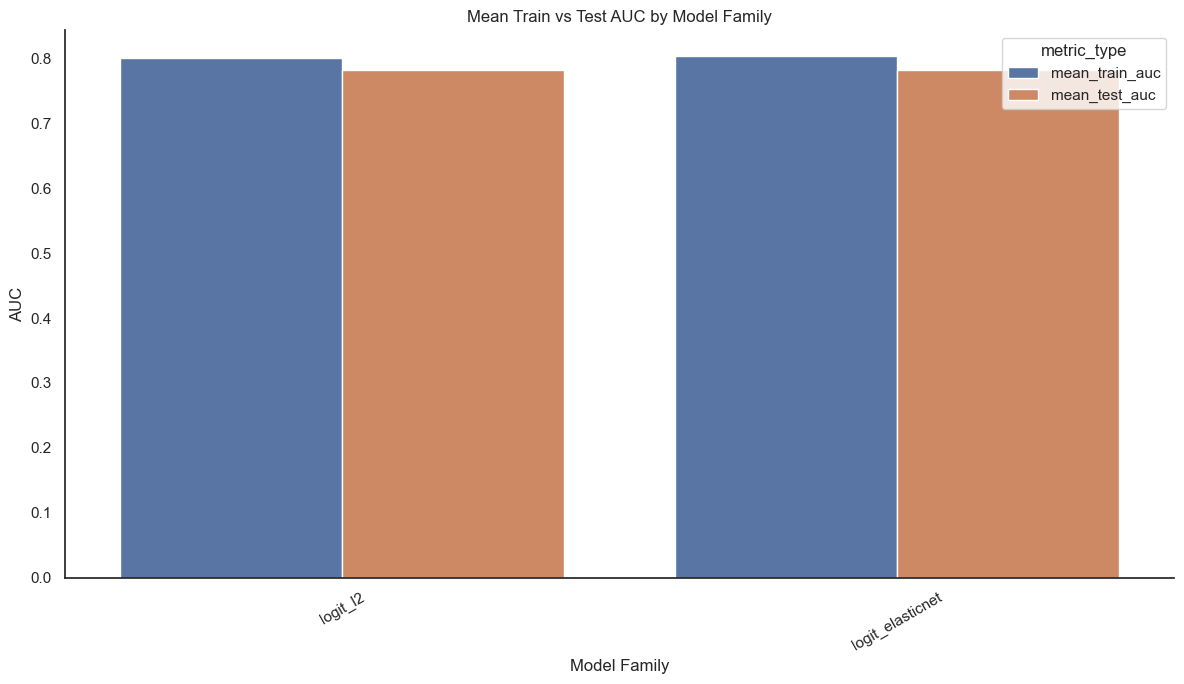

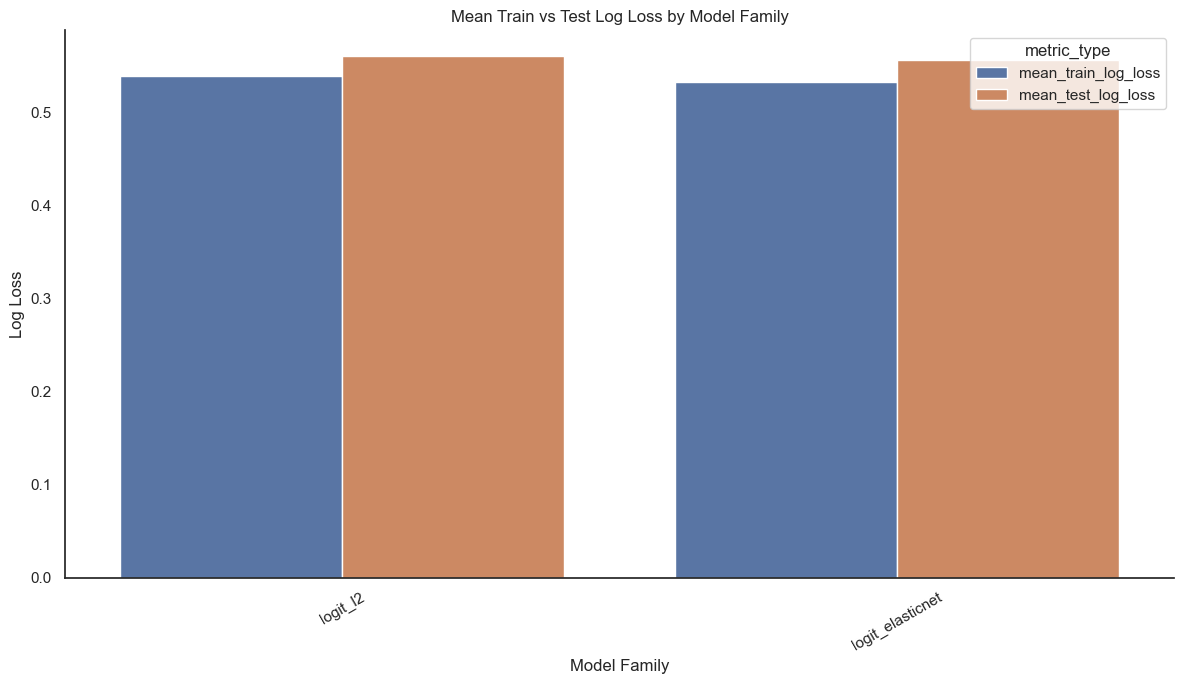

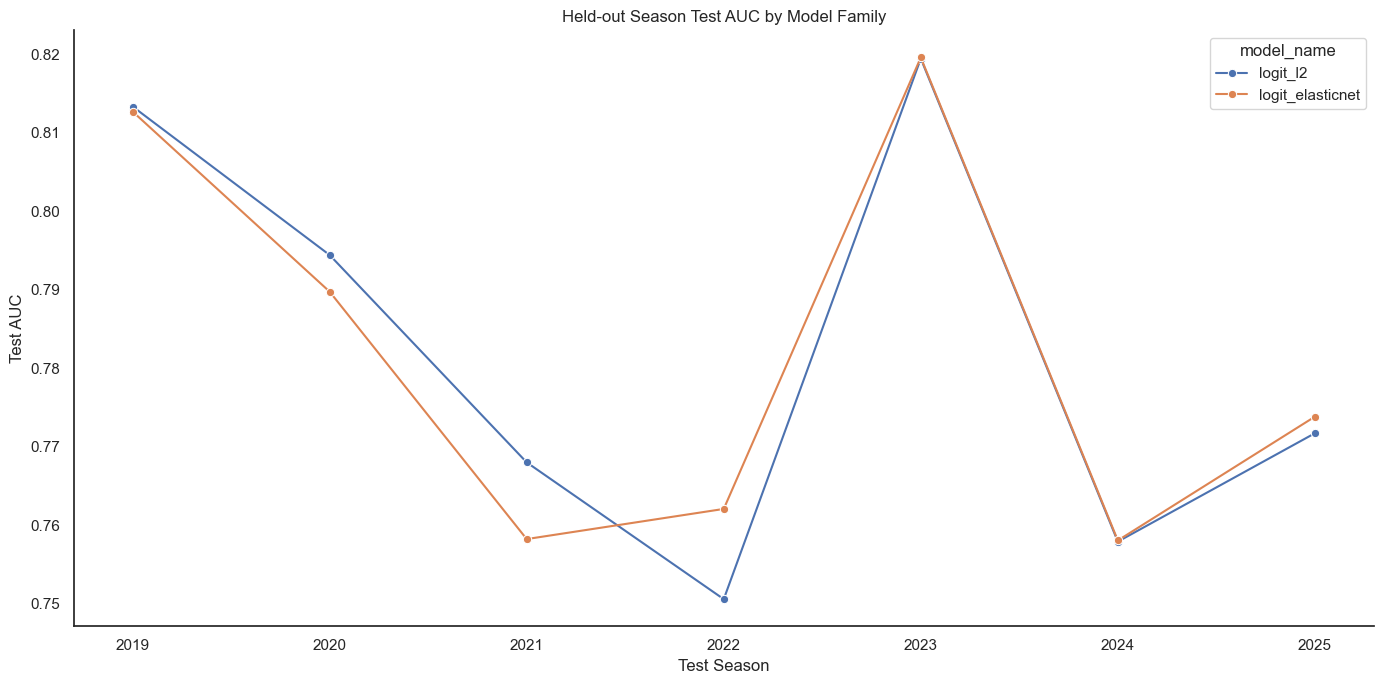

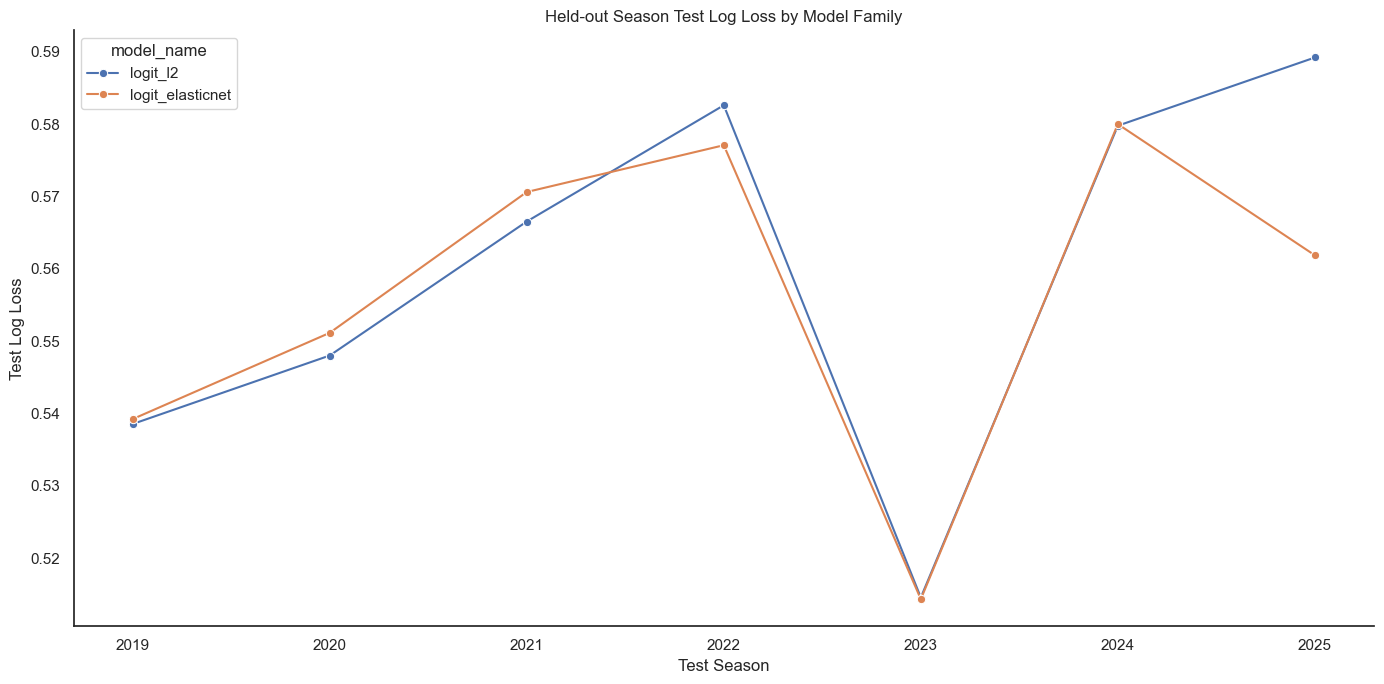

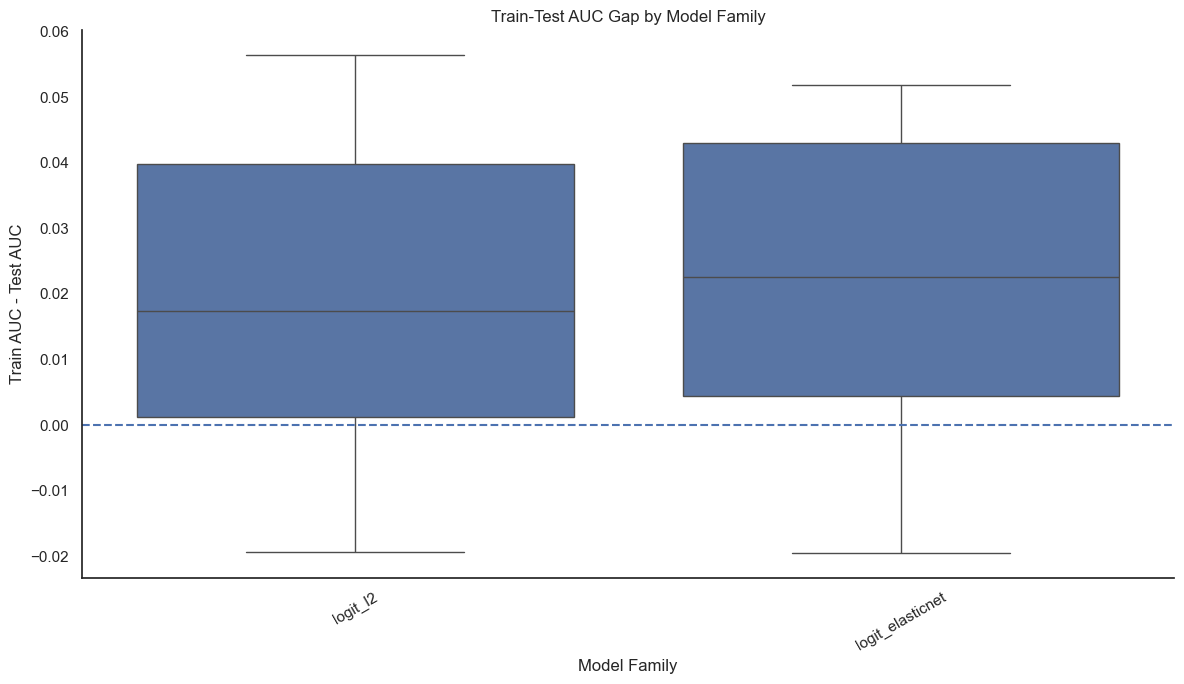

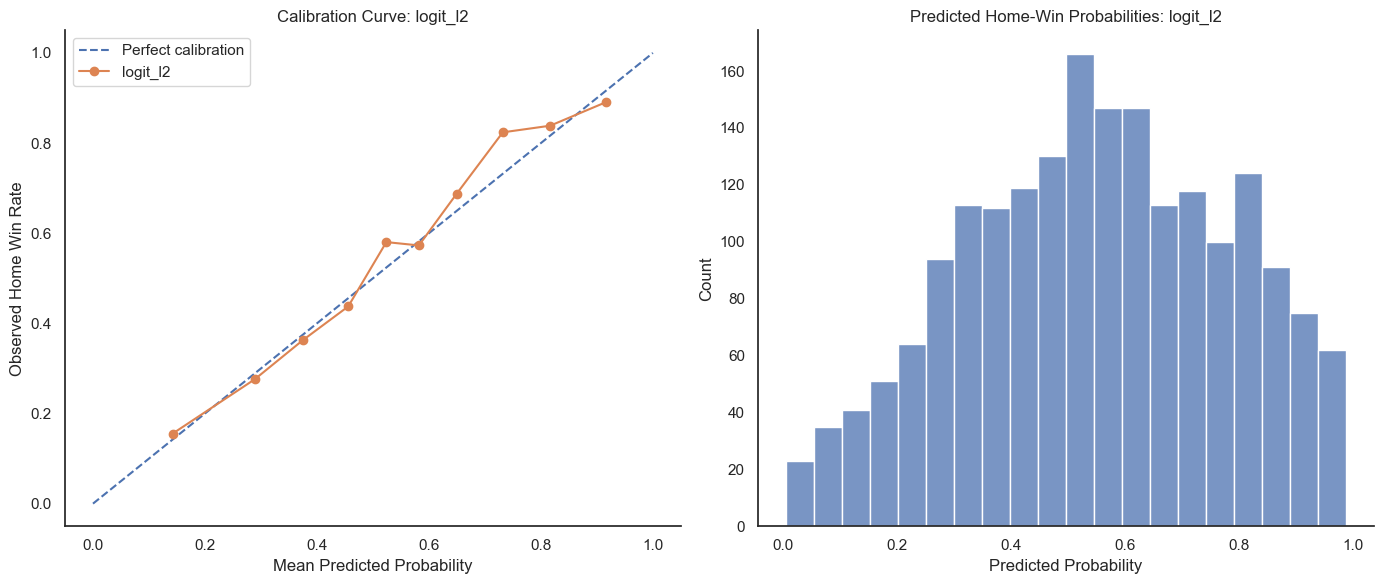

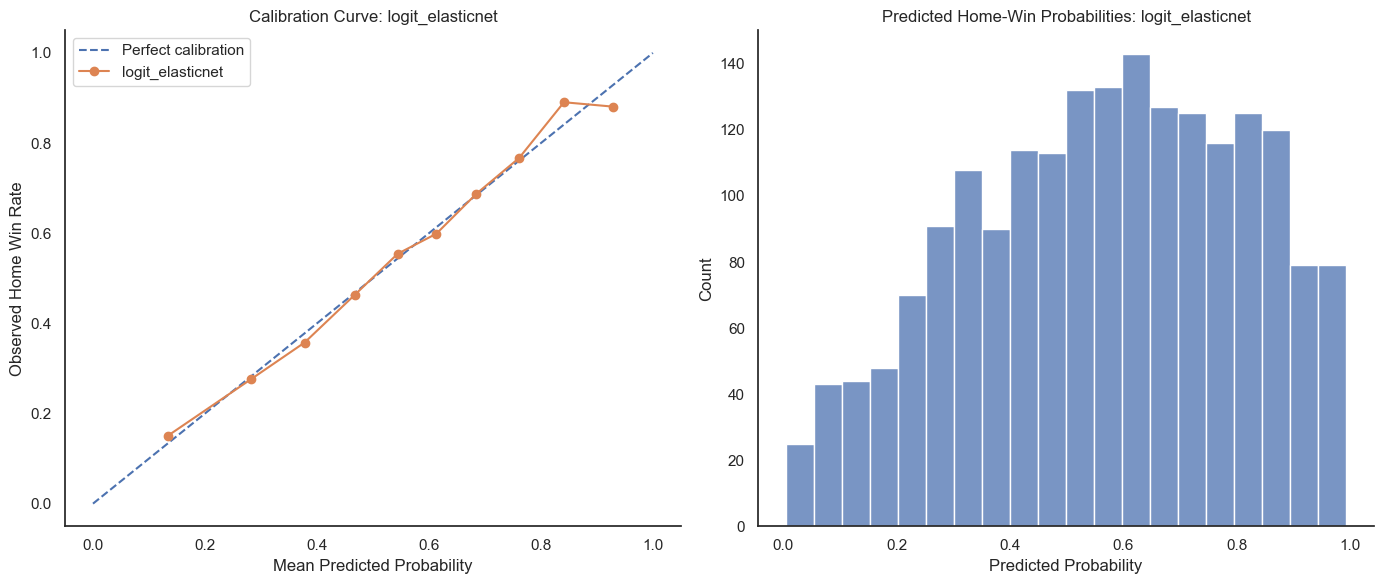

In [29]:
plot_calibration_and_histogram(pred_3df, "logit_l2")
plot_calibration_and_histogram(pred_3df, "logit_elasticnet")


## Expand Tuning Params into Columns

In [30]:
def expand_params_col(df, params_col="params"):
    params_expanded = pd.json_normalize(df[params_col])
    out = pd.concat([df.drop(columns=[params_col]).reset_index(drop=True), params_expanded], axis=1)
    return out

tuning_expanded_3df = expand_params_col(tuning_results_3df, params_col="params")
tuning_expanded_3df.to_csv(project_data_exports_path / 'tuning_expanded_3df.csv', index=False)
tuning_expanded_3df

,model_name,valid_season,valid_auc,valid_log_loss,valid_brier,valid_accuracy,valid_precision,valid_recall,valid_f1,valid_specificity,...,valid_tn,valid_fp,valid_fn,valid_tp,valid_lr_pos,valid_lr_neg,outer_test_season,outer_train_end,C,l1_ratio
0,logit_l2,2018,0.785952,0.577742,0.196325,0.697842,0.751678,0.704403,0.727273,0.689076,...,82,37,47,112,2.265511,0.428977,2019,2018,0.001,NaN
1,logit_l2,2018,0.789916,0.543170,0.184810,0.690647,0.738562,0.710692,0.724359,0.663866,...,79,40,46,113,2.114308,0.435793,2019,2018,0.010,NaN
2,logit_l2,2018,0.792294,0.536944,0.182791,0.719424,0.754717,0.754717,0.754717,0.672269,...,80,39,39,120,2.302854,0.364858,2019,2018,0.100,NaN
3,logit_l2,2018,0.792928,0.536801,0.182574,0.730216,0.759259,0.773585,0.766355,0.672269,...,80,39,36,123,2.360426,0.336792,2019,2018,0.500,NaN
4,logit_l2,2018,0.793404,0.536903,0.182572,0.730216,0.759259,0.773585,0.766355,0.672269,...,80,39,36,123,2.360426,0.336792,2019,2018,1.000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,logit_elasticnet,2024,0.749988,0.583532,0.200154,0.701389,0.731429,0.766467,0.748538,0.611570,...,74,47,39,128,1.973245,0.381858,2025,2024,100.000,0.1
374,logit_elasticnet,2024,0.750037,0.583690,0.200201,0.701389,0.731429,0.766467,0.748538,0.611570,...,74,47,39,128,1.973245,0.381858,2025,2024,100.000,0.3
375,logit_elasticnet,2024,0.750037,0.583892,0.200261,0.701389,0.731429,0.766467,0.748538,0.611570,...,74,47,39,128,1.973245,0.381858,2025,2024,100.000,0.5
376,logit_elasticnet,2024,0.749988,0.584163,0.200343,0.701389,0.731429,0.766467,0.748538,0.611570,...,74,47,39,128,1.973245,0.381858,2025,2024,100.000,0.7


## Logistic Tuning Curves by C


In [31]:
logit_tuning_3df = tuning_expanded_3df[
    tuning_expanded_3df["model_name"].isin([
        "logit_l2",
        # "logit_l1",
        "logit_elasticnet"
    ])
].copy()
logit_tuning_3df.to_csv(project_data_exports_path / 'logit_tuning_3df.csv', index=False)

# For elastic net, average over l1_ratio at each C for a simple first view
logit_tuning_3plot, ax = plt.subplots(1, 1, figsize=(14, 7), facecolor='white')
sns.lineplot(
    data=logit_tuning_3df,
    x="C",
    y="valid_auc",
    hue="model_name",
    marker="o",
    estimator="mean",
    errorbar=None,
    ax=ax
)
ax.set_xscale("log")
ax.set_title("Validation AUC vs C for Regularized Logistic Models")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Validation AUC")
logit_tuning_3plot.tight_layout();
logit_tuning_3plot.savefig(project_data_exports_path / 'logit_tuning_3plot.png', dpi=300, bbox_inches='tight')

## ElasticNet Heatmap C x L1 ratio

Heatmap of mean validation AUC across C and L1 ratio


In [32]:
enet_tuning_3df = tuning_expanded_3df[tuning_expanded_3df["model_name"] == "logit_elasticnet"].copy()
enet_tuning_3df.to_csv(project_data_exports_path / 'enet_tuning_3df.csv', index=False)

enet_pivot_3df = enet_tuning_3df.pivot_table(
    index="l1_ratio",
    columns="C",
    values="valid_auc",
    aggfunc="mean"
)
enet_pivot_3df.to_csv(project_data_exports_path / 'enet_pivot_3df.csv', index=False)

enet_c_l1_3plot, ax = plt.subplots(1, 1, figsize=(10, 6), facecolor='white')
sns.heatmap(enet_pivot_3df, annot=True, fmt=".3f", cmap="viridis")
ax.set_title("Elastic Net Mean Validation AUC")
ax.set_xlabel("C")
ax.set_ylabel("l1_ratio")
enet_c_l1_3plot.tight_layout();
enet_c_l1_3plot.savefig(project_data_exports_path / 'enet_c_l1_3plot.png', dpi=300, bbox_inches='tight')

## Refit Best Overall Logistic on Final Outer Split for Coefs


In [37]:
final_split = fixed_5_splits[-1]
final_test_season = final_split["test_season"]

coef_rows = []

for model_name in [
    "logit_l2",
    # "logit_l1",
    "logit_elasticnet"
]:
    best_row = outer_results_3df[
        (outer_results_3df["model_name"] == model_name) &
        (outer_results_3df["test_season"] == final_test_season)
    ].iloc[0]

    best_params = best_row["best_params"]

    pipe = make_model_pipeline(model_name, main_feature_cols, best_params)

    train_df = df.loc[final_split["train_idx"]].copy()
    X_train = train_df[main_feature_cols]
    y_train = train_df[target_col].astype(int)

    pipe.fit(X_train, y_train)

    model = pipe.named_steps["model"]

    if hasattr(model, "coef_"):
        coef_df = pd.DataFrame({
            "feature": main_feature_cols,
            "coefficient": model.coef_.ravel(),
            "model_name": model_name
        })
        coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
        coef_rows.append(coef_df)

coef_all_3df = pd.concat(coef_rows, ignore_index=True)
coef_all_3df.to_csv(project_data_exports_path / 'coef_all_3df.csv', index=False)
coef_all_3df

,feature,coefficient,model_name,abs_coefficient
0,neutral,-0.022482,logit_l2,0.022482
1,conference_game,0.006303,logit_l2,0.006303
2,ranked_home,0.068566,logit_l2,0.068566
3,ranked_away,-0.045977,logit_l2,0.045977
4,both_ranked,0.032156,logit_l2,0.032156
5,home_pre_games_played_pre,-0.014809,logit_l2,0.014809
6,away_pre_games_played_pre,0.000199,logit_l2,0.000199
7,rank_advantage_home,0.082808,logit_l2,0.082808
8,recruiting_avg_4yr_diff,0.093648,logit_l2,0.093648
9,recruiting_points_mean_4yr_diff,0.091275,logit_l2,0.091275


## Plot Top Coefficients for Each Regularized Logistic Model

Plots largest positive and negative coefficient for each family




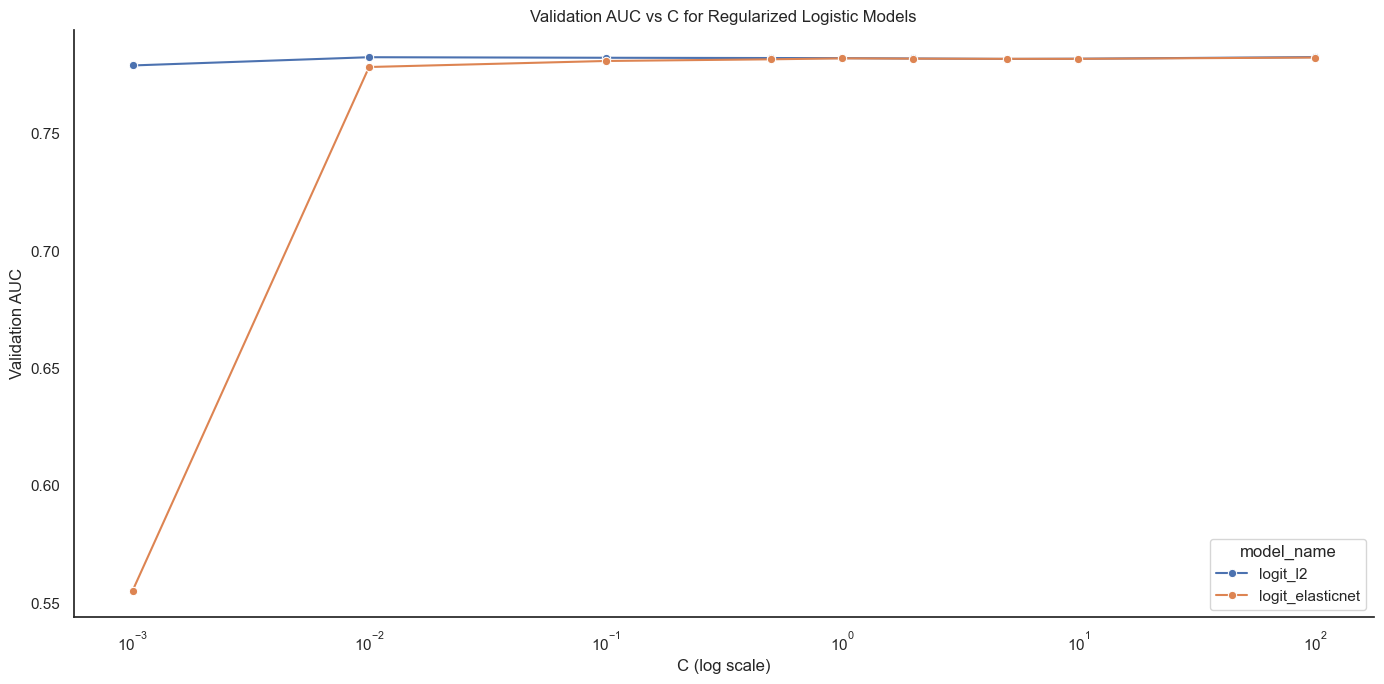

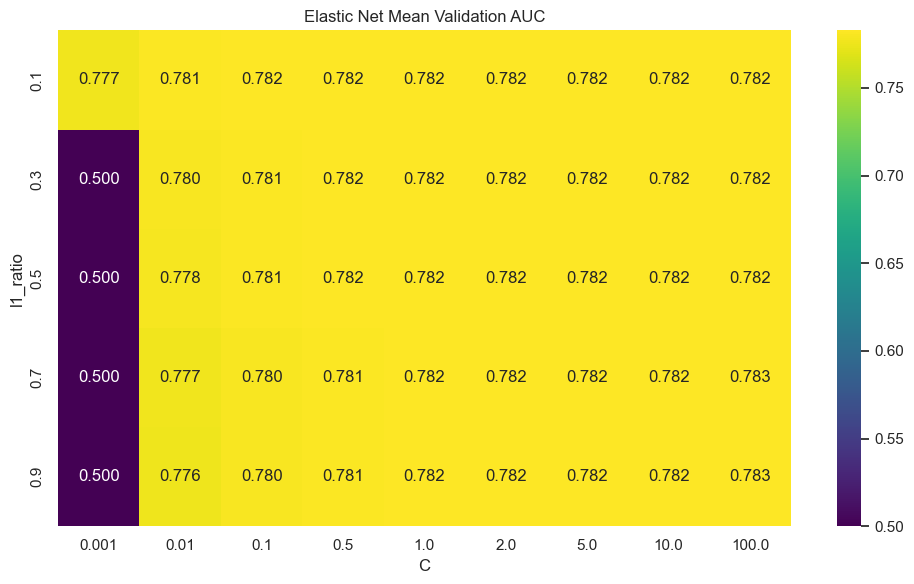

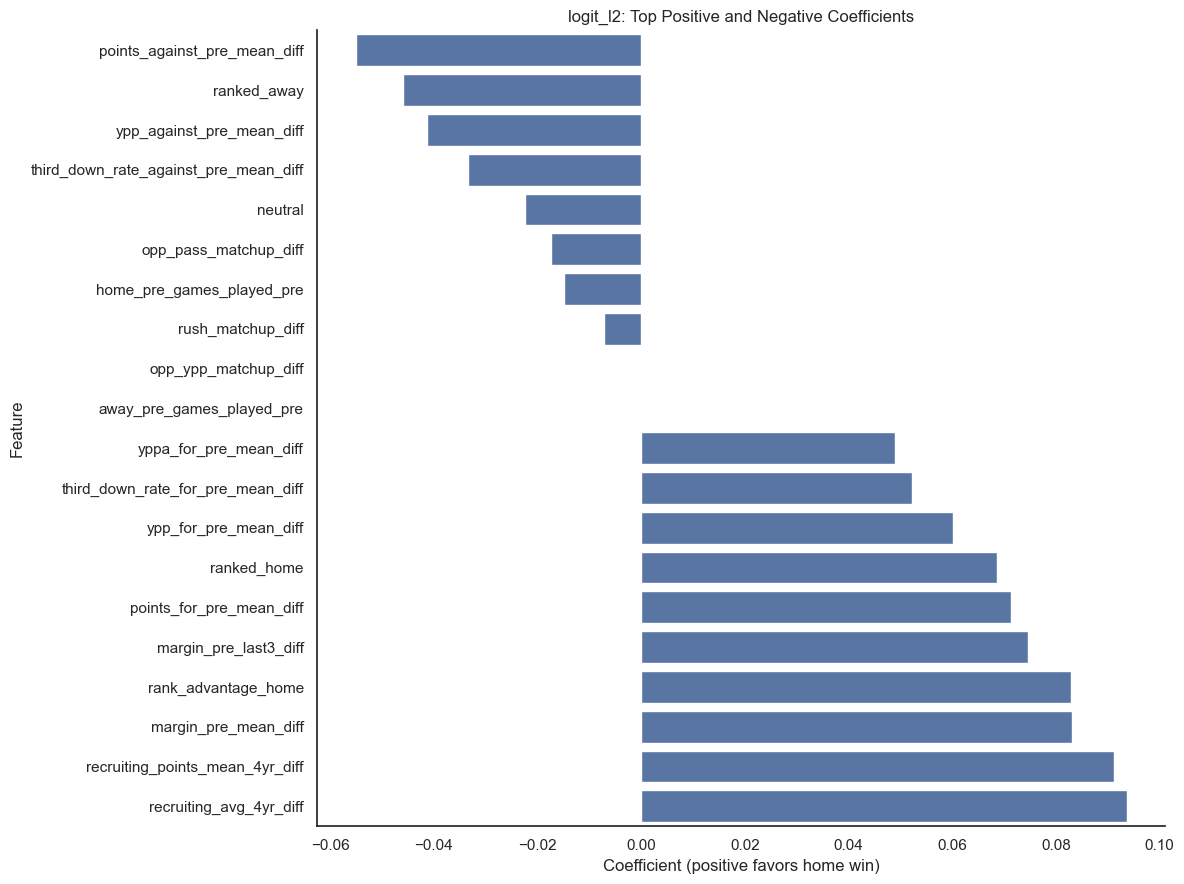

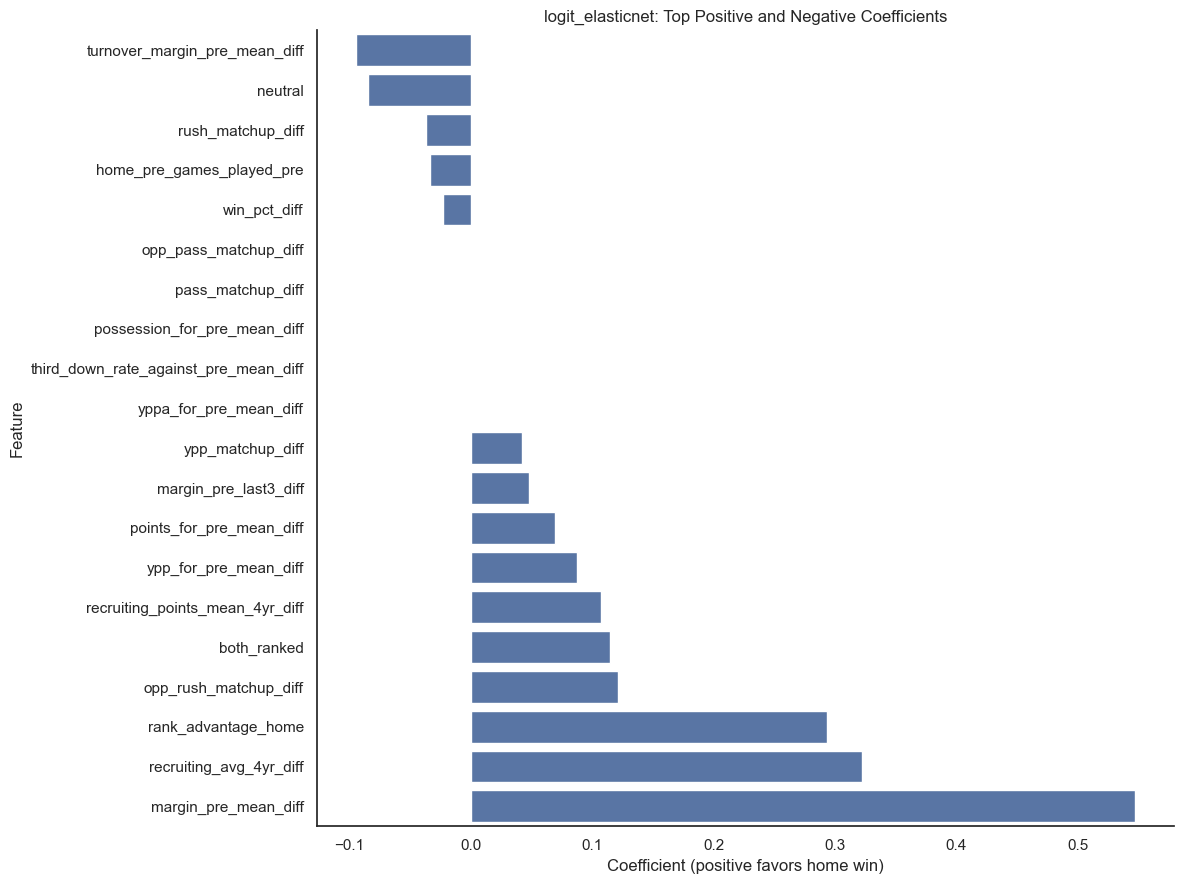

In [38]:
for model_name in [
    "logit_l2",
    # "logit_l1",
    "logit_elasticnet"
]:
    temp = coef_all_3df[coef_all_3df["model_name"] == model_name].copy()
    temp = temp.sort_values("coefficient")
    temp_plot = pd.concat([temp.head(10), temp.tail(10)])

    plt.figure(figsize=(12, 9))
    sns.barplot(
        data=temp_plot,
        y="feature",
        x="coefficient"
    )
    plt.title(f"{model_name}: Top Positive and Negative Coefficients")
    plt.xlabel("Coefficient (positive favors home win)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show();

## Sparsity Check for L2 / ElasticNet

Counts the number of nonzero coefficients for L2 and Elasticnet


In [39]:
sparse_summary = []

for model_name in [
    # "logit_l1",
    "logit_elasticnet"
]:
    temp = coef_all_3df[coef_all_3df["model_name"] == model_name].copy()
    nonzero = (temp["coefficient"] != 0).sum()
    sparse_summary.append({
        "model_name": model_name,
        "nonzero_coefficients": nonzero,
        "total_coefficients": len(temp),
        "sparsity_rate": 1 - (nonzero / len(temp))
    })

sparse_summary_3df = pd.DataFrame(sparse_summary)
sparse_summary_3df

,model_name,nonzero_coefficients,total_coefficients,sparsity_rate
0,logit_elasticnet,18,29,0.37931


## Permutation Importance on Final Outer Season Test


In [40]:
perm_rows = []

for model_name in model_families:
    pipe = fitted_models[(model_name, final_test_season)]

    test_df = df.loc[final_split["test_idx"]].copy()
    X_test = test_df[main_feature_cols]
    y_test = test_df[target_col].astype(int)

    perm = permutation_importance(
        estimator=pipe,
        X=X_test,
        y=y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    temp = pd.DataFrame({
        "feature": main_feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
        "model_name": model_name
    }).sort_values("importance_mean", ascending=False)

    perm_rows.append(temp)

perm_all_3df = pd.concat(perm_rows, ignore_index=True)
perm_all_3df.to_csv(project_data_exports_path / 'perm_all_3df.csv', index=False)
perm_all_3df

,feature,importance_mean,importance_std,model_name
0,margin_pre_mean_diff,0.009083,0.005182,logit_l2
1,margin_pre_last3_diff,0.006982,0.004643,logit_l2
2,points_against_pre_mean_diff,0.006722,0.003646,logit_l2
3,ranked_away,0.006641,0.002962,logit_l2
4,ypp_for_pre_mean_diff,0.005292,0.002960,logit_l2
5,rank_advantage_home,0.004469,0.004264,logit_l2
6,yppa_for_pre_mean_diff,0.004439,0.002803,logit_l2
7,points_for_pre_mean_diff,0.004336,0.004138,logit_l2
8,recruiting_points_mean_4yr_diff,0.003435,0.003704,logit_l2
9,ypp_against_pre_mean_diff,0.003290,0.002645,logit_l2


## Plot Top Permutation Importances by Model
Plots the top 15 permutation importance features for each model family

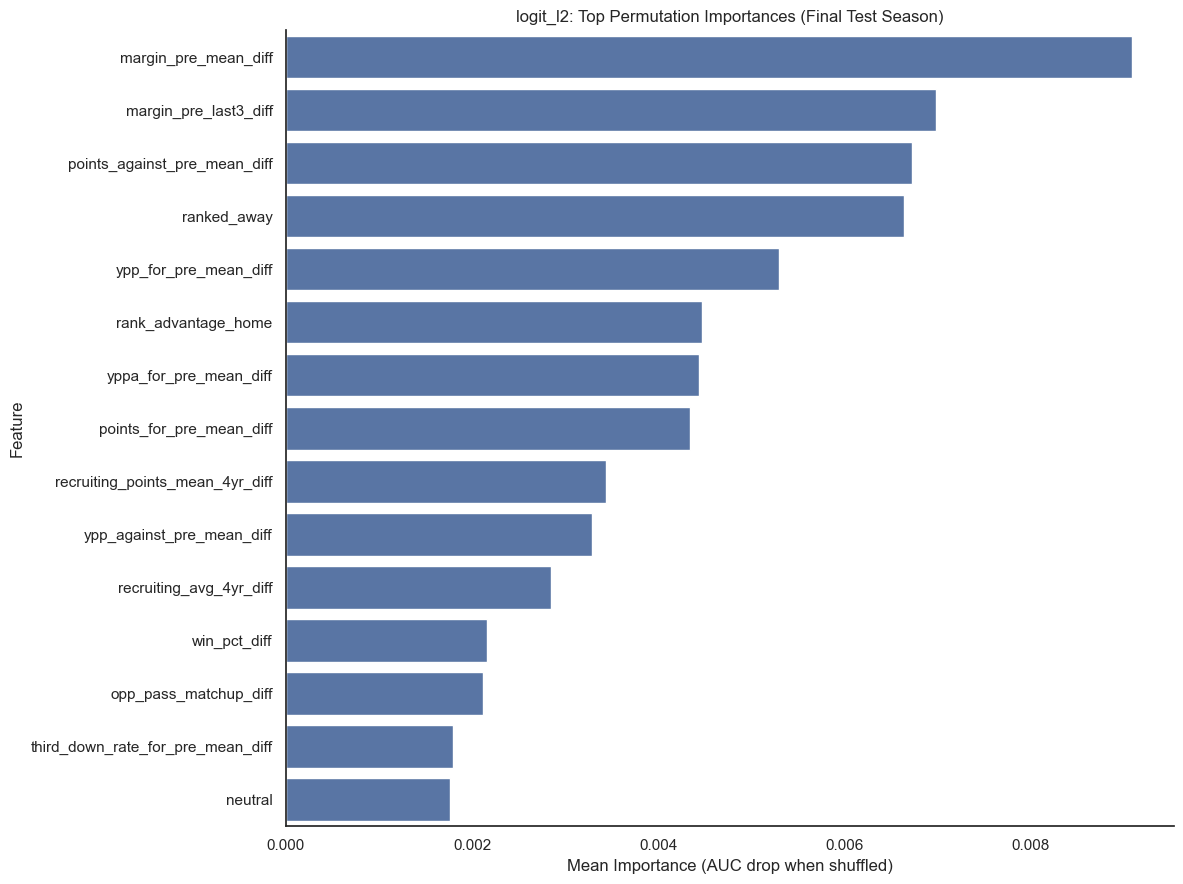

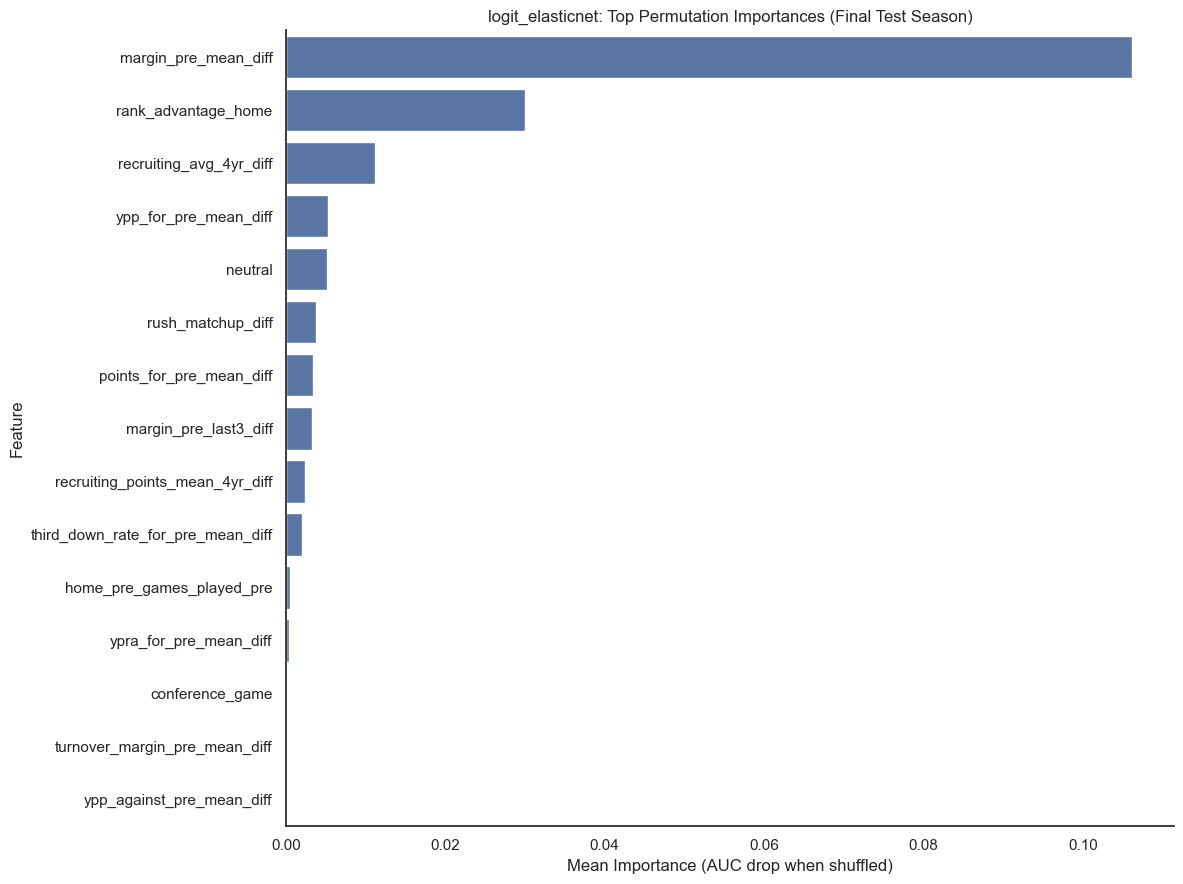

In [41]:
for model_name in model_families:
    temp = perm_all_3df[perm_all_3df["model_name"] == model_name].copy()
    temp = temp.sort_values("importance_mean", ascending=False).head(15)

    plt.figure(figsize=(12, 9))
    sns.barplot(
        data=temp,
        y="feature",
        x="importance_mean"
    )
    plt.title(f"{model_name}: Top Permutation Importances (Final Test Season)")
    plt.xlabel("Mean Importance (AUC drop when shuffled)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show();

## Comparison Leaderboard

In [42]:
leaderboard_cols = [
    "model_name",
    "mean_train_auc",
    "mean_test_auc",
    "mean_auc_gap",
    "mean_train_log_loss",
    "mean_test_log_loss",
    "mean_log_loss_gap",
    "mean_test_brier",
    "mean_test_accuracy",
    "std_test_auc",
    "n_splits",
]

leaderboard_3df = summary_3df[leaderboard_cols].copy()
leaderboard_3df.to_csv(project_data_exports_path / 'leaderboard_3df.csv', index=False)
leaderboard_3df

,model_name,mean_train_auc,mean_test_auc,mean_auc_gap,mean_train_log_loss,mean_test_log_loss,mean_log_loss_gap,mean_test_brier,mean_test_accuracy,std_test_auc,n_splits
0,logit_l2,0.801698,0.782205,0.019492,0.538599,0.559894,0.021296,0.189069,0.715134,0.027111,7
1,logit_elasticnet,0.803455,0.782036,0.021419,0.532524,0.556326,0.023801,0.187724,0.715917,0.025883,7


## Plot Mean Test AUC Leaderboard

Plots mean held-out test auc by model family


In [43]:
mean_test_auc_leaderboard_3plot, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')
sns.barplot(
    data=summary_3df.sort_values("mean_test_auc", ascending=False),
    x="mean_test_auc",
    y="model_name",
    ax=ax
)
ax.set_title("Model Family Comparison: Mean Held-out Test AUC")
ax.set_xlabel("Mean Test AUC")
ax.set_ylabel("Model Family")
mean_test_auc_leaderboard_3plot.tight_layout();
mean_test_auc_leaderboard_3plot.savefig(project_data_exports_path / 'mean_test_auc_leaderboard_3plot.png', dpi=300, bbox_inches='tight')

## Plot Mean Test Log Loss Leaderboard

Plots mean held-out test log loss by model family


In [44]:
mean_test_log_loss_leaderboard_3plot, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')
sns.barplot(
    data=summary_3df.sort_values("mean_test_log_loss", ascending=True),
    x="mean_test_log_loss",
    y="model_name",
    ax=ax
)
ax.set_title("Model Family Comparison: Mean Held-out Test Log Loss")
ax.set_xlabel("Mean Test Log Loss")
ax.set_ylabel("Model Family")
mean_test_log_loss_leaderboard_3plot.tight_layout();
mean_test_log_loss_leaderboard_3plot.savefig(project_data_exports_path / 'mean_test_log_loss_leaderboard_3plot.png', dpi=300, bbox_inches='tight')

## Plot Performance vs Overfitting

Scatterplot of mean train-test auc gap vs mean test auc


In [45]:
mean_train_test_auc_gap_vs_mean_test_auc_3plot, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')
sns.scatterplot(
    data=summary_3df,
    x="mean_auc_gap",
    y="mean_test_auc",
    hue="model_name",
    s=150,
    ax=ax
)

for _, row in summary_3df.iterrows():
    plt.text(row["mean_auc_gap"], row["mean_test_auc"], row["model_name"])

ax.set_title("Model Family Comparison: Test AUC vs Overfitting Gap")
ax.set_xlabel("Mean Train-Test AUC Gap")
ax.set_ylabel("Mean Test AUC")
mean_train_test_auc_gap_vs_mean_test_auc_3plot.tight_layout();
mean_train_test_auc_gap_vs_mean_test_auc_3plot.savefig(project_data_exports_path / 'mean_train_test_auc_gap_vs_mean_test_auc_3plot.png', dpi=300, bbox_inches='tight')

## Full Tiered Comparison Across All Model Families



In [46]:
tiered_results = []

for feature_set_name, feature_cols in feature_sets.items():
    print(f"\nRunning feature set: {feature_set_name}")

    for model_name in model_families:
        print(f"  Model: {model_name}")

        for outer_split in fixed_5_splits:
            out = tune_model_for_outer_split(
                df=df,
                outer_split=outer_split,
                feature_cols=feature_cols,
                target_col=target_col,
                model_name=model_name,
                param_grid=param_grids[model_name],
                selection_metric="auc"
            )

            if out is None:
                continue

            result_row, tuning_df, fitted_pipe = out
            result_row["feature_set_name"] = feature_set_name
            tiered_results.append(result_row)

tiered_results_3df = pd.DataFrame(tiered_results)
tiered_results_3df.to_csv(project_data_exports_path / 'tiered_results_3df.csv', index=False)
tiered_results_3df


Running feature set: baseline
  Model: logit_l2
  Model: logit_elasticnet

Running feature set: baseline_matchup
  Model: logit_l2
  Model: logit_elasticnet

Running feature set: baseline_talent
  Model: logit_l2
  Model: logit_elasticnet

Running feature set: baseline_performance
  Model: logit_l2
  Model: logit_elasticnet

Running feature set: baseline_talent_performance
  Model: logit_l2
  Model: logit_elasticnet

Running feature set: full
  Model: logit_l2
  Model: logit_elasticnet


,model_name,best_params,train_start,train_end,test_season,n_train,n_test,train_auc,train_log_loss,train_brier,...,test_balanced_accuracy,test_tn,test_fp,test_fn,test_tp,test_lr_pos,test_lr_neg,auc_gap,log_loss_gap,feature_set_name
0,logit_l2,{'C': 100},2014,2018,2019,1379,276,0.736307,0.594327,0.204446,...,0.646795,56,64,27,129,1.550481,0.370879,-0.016310,-0.021283,baseline
1,logit_l2,{'C': 100},2015,2019,2020,1383,222,0.739280,0.586292,0.201554,...,0.631721,37,63,13,109,1.418163,0.287993,0.007190,0.011981,baseline
2,logit_l2,{'C': 100},2016,2020,2021,1336,282,0.741718,0.586282,0.201599,...,0.608333,46,74,27,135,1.351351,0.434783,0.042387,0.029259,baseline
3,logit_l2,{'C': 0.001},2017,2021,2022,1336,279,0.725258,0.640694,0.224200,...,0.614516,46,78,22,133,1.364103,0.382609,0.073671,0.015638,baseline
4,logit_l2,{'C': 100},2018,2022,2023,1337,291,0.715767,0.597466,0.206810,...,0.680807,57,72,13,149,1.647891,0.181611,-0.064355,-0.047474,baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,logit_elasticnet,"{'C': 0.01, 'l1_ratio': 0.1}",2016,2020,2021,1336,282,0.800373,0.539249,0.181237,...,0.655710,67,53,40,122,1.705101,0.442233,0.042143,0.031368,full
80,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.9}",2017,2021,2022,1336,279,0.813978,0.519884,0.173848,...,0.710484,73,51,26,129,2.023529,0.284932,0.051907,0.057198,full
81,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.9}",2018,2022,2023,1337,291,0.800142,0.534535,0.179668,...,0.722150,82,47,31,131,2.219464,0.301039,-0.019458,-0.020202,full
82,logit_elasticnet,"{'C': 100, 'l1_ratio': 0.9}",2019,2023,2024,1350,288,0.802074,0.532330,0.178849,...,0.689019,74,47,39,128,1.973245,0.381858,0.044020,0.047672,full


## Tiered Comparison Summary

Aggregates the tiered results by feature set and model family


In [47]:
tiered_summary_3df = (
    tiered_results_3df
    .groupby(["feature_set_name", "model_name"], as_index=False)
    .agg(
        mean_test_auc=("test_auc", "mean"),
        mean_test_log_loss=("test_log_loss", "mean"),
        mean_auc_gap=("auc_gap", "mean"),
        mean_test_accuracy=("test_accuracy", "mean"),
        n_splits=("test_season", "count"),
    )
    .sort_values(["feature_set_name", "mean_test_auc"], ascending=[True, False])
)

tiered_summary_3df.to_csv(project_data_exports_path / 'tiered_summary_3df.csv', index=False)
tiered_summary_3df

,feature_set_name,model_name,mean_test_auc,mean_test_log_loss,mean_auc_gap,mean_test_accuracy,n_splits
0,baseline,logit_elasticnet,0.723533,0.606699,0.008073,0.665827,7
1,baseline,logit_l2,0.721813,0.599917,0.010289,0.667473,7
3,baseline_matchup,logit_l2,0.731344,0.599275,0.014288,0.669703,7
2,baseline_matchup,logit_elasticnet,0.729138,0.598883,0.014933,0.671856,7
4,baseline_performance,logit_elasticnet,0.769836,0.572532,0.016379,0.710359,7
5,baseline_performance,logit_l2,0.767692,0.571020,0.019863,0.708185,7
7,baseline_talent,logit_l2,0.747303,0.589090,0.015915,0.684245,7
6,baseline_talent,logit_elasticnet,0.747176,0.584121,0.016242,0.682952,7
9,baseline_talent_performance,logit_l2,0.779057,0.561634,0.019752,0.714408,7
8,baseline_talent_performance,logit_elasticnet,0.777209,0.561745,0.018726,0.713292,7


## Plot Tiered Comparison

Plots mean held-out test auc by feature set and model family



In [48]:
mean_held_out_test_auc_by_feature_set_model_fam_tiered_3plot, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='white')
sns.barplot(
    data=tiered_summary_3df,
    x="feature_set_name",
    y="mean_test_auc",
    hue="model_name",
    ax=ax
)
ax.set_title("Mean Held-out Test AUC by Feature Set and Model Family")
ax.set_xlabel("Feature Set")
ax.set_ylabel("Mean Test AUC")
ax.tick_params(axis='x', labelrotation=30)
mean_held_out_test_auc_by_feature_set_model_fam_tiered_3plot.tight_layout()
mean_held_out_test_auc_by_feature_set_model_fam_tiered_3plot.savefig(project_data_exports_path / 'mean_held_out_test_auc_by_feature_set_model_fam_tiered_3plot.png', dpi=300, bbox_inches='tight')